In [2]:
import json
import os
import re

import fsspec
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

from experiments.data_quality_scaling.utils import read_eval_metrics, get_final_metrics
from marin.execution.executor import Executor

PREFIX = "gs://marin-us-central2"

/Users/rohith/research/marin/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
2026-03-21 20:21:24,831	INFO util.py:154 -- Missing packages: ['ipywidgets']. Run `pip install -U ipywidgets`, then restart the notebook server for rich notebook output.


# Isoflop Random Baseline: Original vs Sweep

Compare results from `exp_data_quality_scaling_random.py` (original) and `exp_data_quality_scaling_random_sweep.py` (sweep with more data, more anneal steps).

## Original random baseline (`exp_data_quality_scaling_random.py`)

In [3]:
from experiments.data_quality_scaling.isoflop.exp_data_quality_scaling_random import (
    build_steps as build_rand_steps,
    MODELS as RAND_MODELS,
    STEP_COUNTS as RAND_STEP_COUNTS,
    HIDDEN_SIZES as RAND_HIDDEN_SIZES,
)

rand_all_steps = build_rand_steps()
rand_executor = Executor(prefix=PREFIX, executor_info_base_path=os.path.join(PREFIX, "experiments"))
for step in rand_all_steps:
    rand_executor.compute_version(step, is_pseudo_dep=False)

rand_train_steps = [s for s in rand_all_steps if "dq-iso-rand-train-" in s.name]
rand_tune_steps = [s for s in rand_all_steps if "dq-iso-rand-tune-" in s.name]
rand_select_steps = [s for s in rand_all_steps if s.name.startswith("select-best-lr/")]

print(f"{len(rand_all_steps)} total steps: {len(rand_tune_steps)} tuning, {len(rand_select_steps)} select, {len(rand_train_steps)} training")

38 total steps: 20 tuning, 4 select, 12 training


In [4]:
# Read metrics for original random baseline training runs
rand_rows = []
for step in rand_train_steps:
    m = re.search(r"dq-iso-rand-train-(\w+)-steps(\d+)", step.name)
    if not m:
        print(f"Could not parse step name: {step.name}")
        continue
    model_name = m.group(1)
    num_steps = int(m.group(2))
    total_tokens_M = num_steps * 128 * 1024 / 1e6

    out_path = rand_executor.output_paths[step]
    try:
        metrics = get_final_metrics(out_path)
    except Exception as e:
        print(f"Failed to read metrics for {step.name}: {e}")
        continue

    rand_rows.append({
        "model": model_name,
        "num_steps": num_steps,
        "total_tokens_M": total_tokens_M,
        "high_loss": metrics.get("eval/high/loss"),
        "low_loss": metrics.get("eval/low/loss"),
        "final_step": metrics.get("step"),
        "source": "original",
        "hq_anneal_steps": 500,
    })

df_rand = pd.DataFrame(rand_rows)
print(f"Loaded {len(df_rand)} original random baseline training runs")
df_rand

/Users/rohith/research/marin/.venv/lib/python3.11/site-packages/google/auth/_default.py:114: UserWarning: Your application has authenticated using end user credentials from Google Cloud SDK without a quota project. You might receive a "quota exceeded" or "API not enabled" error. See the following page for troubleshooting: https://cloud.google.com/docs/authentication/adc-troubleshooting/user-creds. 
  warnings.warn(_CLOUD_SDK_CREDENTIALS_WARNING)


Loaded 12 original random baseline training runs


,model,num_steps,total_tokens_M,high_loss,low_loss,final_step,source,hq_anneal_steps
0,128h,100,13.107200,5.120084,8.336539,599,original,500
1,128h,1172,153.616384,4.826397,7.959354,1671,original,500
2,128h,2344,307.232768,4.805964,7.803445,2843,original,500
3,256h,100,13.107200,4.787830,8.132169,599,original,500
4,256h,1172,153.616384,4.400722,7.650667,1671,original,500
5,256h,2344,307.232768,4.432890,7.526549,2843,original,500
6,512h,100,13.107200,4.456062,7.793405,599,original,500
7,512h,1172,153.616384,4.217353,7.279151,1671,original,500
8,512h,2344,307.232768,4.247797,7.154037,2843,original,500
9,768h,100,13.107200,4.350482,7.699122,599,original,500


## Sweep experiment (`exp_data_quality_scaling_random_sweep.py`)

In [5]:
from experiments.data_quality_scaling.isoflop.exp_data_quality_scaling_random_sweep import (
    build_steps as build_sweep_steps,
    MODELS as SWEEP_MODELS,
    STEP_COUNTS as SWEEP_STEP_COUNTS,
    HQ_ANNEAL_STEPS as SWEEP_HQ_ANNEAL_STEPS,
    HIDDEN_SIZES as SWEEP_HIDDEN_SIZES,
)
from marin.execution.executor import unwrap_versioned_value

sweep_all_steps = build_sweep_steps()
sweep_executor = Executor(prefix=PREFIX, executor_info_base_path=os.path.join(PREFIX, "experiments"))
for step in sweep_all_steps:
    sweep_executor.compute_version(step, is_pseudo_dep=False)

sweep_train_steps = [s for s in sweep_all_steps if "dq-iso-rand-train-" in s.name]
sweep_tune_steps = [s for s in sweep_all_steps if "dq-iso-rand-tune-" in s.name]
sweep_select_steps = [s for s in sweep_all_steps if s.name.startswith("select-best-lr/")]

print(f"{len(sweep_all_steps)} total steps: {len(sweep_tune_steps)} tuning, {len(sweep_select_steps)} select, {len(sweep_train_steps)} training")

86 total steps: 20 tuning, 4 select, 60 training


In [6]:
# Read metrics for sweep training runs
sweep_rows = []
for step in sweep_train_steps:
    m = re.search(r"dq-iso-rand-train-(\w+)-steps(\d+)", step.name)
    if not m:
        print(f"Could not parse step name: {step.name}")
        continue
    model_name = m.group(1)
    num_steps = int(m.group(2))

    # Extract hq_anneal_steps from the config
    total_steps = unwrap_versioned_value(step.config.train_pod_config.train_config.trainer.num_train_steps)
    hq_anneal_steps = total_steps - num_steps
    total_tokens_M = total_steps * 128 * 1024 / 1e6

    out_path = sweep_executor.output_paths[step]
    try:
        metrics = get_final_metrics(out_path)
    except Exception as e:
        print(f"Failed to read metrics for {step.name} (anneal={hq_anneal_steps}): {e}")
        continue

    sweep_rows.append({
        "model": model_name,
        "num_steps": num_steps,
        "total_tokens_M": total_tokens_M,
        "high_loss": metrics.get("eval/high/loss"),
        "low_loss": metrics.get("eval/low/loss"),
        "final_step": metrics.get("step"),
        "source": "sweep",
        "hq_anneal_steps": hq_anneal_steps,
    })

df_sweep = pd.DataFrame(sweep_rows)
print(f"Loaded {len(df_sweep)} sweep training runs")
df_sweep

Loaded 60 sweep training runs


,model,num_steps,total_tokens_M,high_loss,low_loss,final_step,source,hq_anneal_steps
0,128h,100,78.643200,5.268388,8.402321,599,sweep,500
1,128h,100,144.179200,4.898686,8.313115,1099,sweep,1000
2,128h,100,275.251200,4.687247,8.145020,2099,sweep,2000
3,128h,1172,219.152384,4.838562,8.028919,1671,sweep,500
4,128h,1172,284.688384,4.659622,8.017706,2171,sweep,1000
5,128h,1172,415.760384,4.566773,7.976083,3171,sweep,2000
6,128h,2344,372.768768,4.777380,7.856225,2843,sweep,500
7,128h,2344,438.304768,4.626429,7.958429,3343,sweep,1000
8,128h,2344,569.376768,4.544268,7.970152,4343,sweep,2000
9,128h,4688,680.001536,4.842796,7.759769,5187,sweep,500


In [7]:
# Combine both dataframes
df_all = pd.concat([df_rand, df_sweep], ignore_index=True)
print(f"Combined: {len(df_all)} runs ({len(df_rand)} original + {len(df_sweep)} sweep)")
df_all

Combined: 72 runs (12 original + 60 sweep)


,model,num_steps,total_tokens_M,high_loss,low_loss,final_step,source,hq_anneal_steps
0,128h,100,13.107200,5.120084,8.336539,599,original,500
1,128h,1172,153.616384,4.826397,7.959354,1671,original,500
2,128h,2344,307.232768,4.805964,7.803445,2843,original,500
3,256h,100,13.107200,4.787830,8.132169,599,original,500
4,256h,1172,153.616384,4.400722,7.650667,1671,original,500
...,...,...,...,...,...,...,...,...
67,768h,4688,745.537536,3.891144,7.146493,5687,sweep,1000
68,768h,4688,876.609536,3.653248,7.064242,6687,sweep,2000
69,768h,9375,1294.336000,4.321590,7.047129,9874,sweep,500
70,768h,9375,1359.872000,3.979800,7.138188,10374,sweep,1000


## Plots

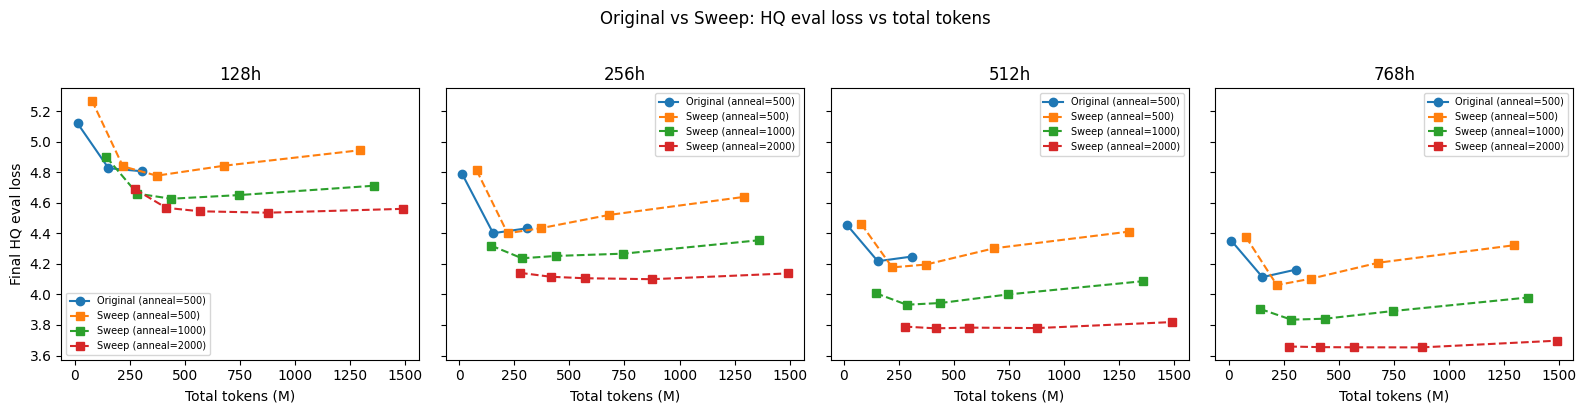

In [8]:
# HQ eval loss vs total tokens, faceted by model, colored by source
models_sorted = [m.name for m in RAND_MODELS]
fig, axes = plt.subplots(1, len(models_sorted), figsize=(4 * len(models_sorted), 4), sharey=True)

for ax, model in zip(axes, models_sorted):
    # Original baseline
    orig = df_all[(df_all["model"] == model) & (df_all["source"] == "original")].sort_values("total_tokens_M")
    if len(orig) > 0:
        ax.plot(orig["total_tokens_M"], orig["high_loss"], "o-", color="tab:blue", label="Original (anneal=500)")

    # Sweep runs, one line per hq_anneal_steps
    colors = {"500": "tab:orange", "1000": "tab:green", "2000": "tab:red"}
    for anneal in sorted(df_all[df_all["source"] == "sweep"]["hq_anneal_steps"].unique()):
        subset = df_all[(df_all["model"] == model) & (df_all["source"] == "sweep") & (df_all["hq_anneal_steps"] == anneal)]
        subset = subset.sort_values("total_tokens_M")
        if len(subset) > 0:
            ax.plot(subset["total_tokens_M"], subset["high_loss"], "s--",
                    color=colors.get(str(int(anneal)), "tab:gray"), label=f"Sweep (anneal={int(anneal)})")

    ax.set_xlabel("Total tokens (M)")
    ax.set_title(f"{model}")
    ax.legend(fontsize=7)

axes[0].set_ylabel("Final HQ eval loss")
fig.suptitle("Original vs Sweep: HQ eval loss vs total tokens", y=1.02)
plt.tight_layout()
plt.show()

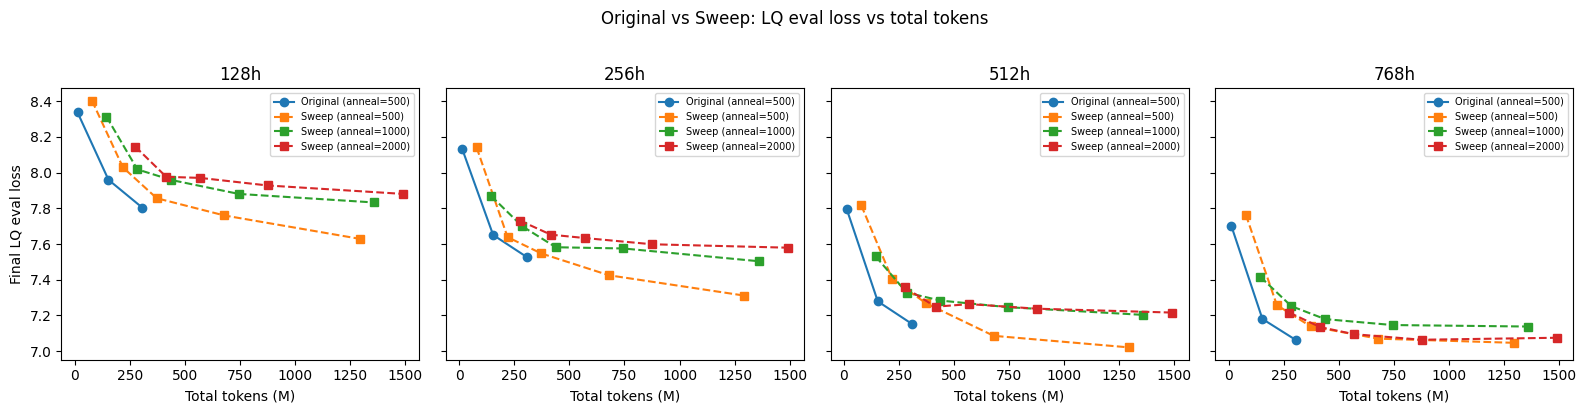

In [9]:
# LQ eval loss vs total tokens, faceted by model
fig, axes = plt.subplots(1, len(models_sorted), figsize=(4 * len(models_sorted), 4), sharey=True)

for ax, model in zip(axes, models_sorted):
    orig = df_all[(df_all["model"] == model) & (df_all["source"] == "original")].sort_values("total_tokens_M")
    if len(orig) > 0:
        ax.plot(orig["total_tokens_M"], orig["low_loss"], "o-", color="tab:blue", label="Original (anneal=500)")

    colors = {"500": "tab:orange", "1000": "tab:green", "2000": "tab:red"}
    for anneal in sorted(df_all[df_all["source"] == "sweep"]["hq_anneal_steps"].unique()):
        subset = df_all[(df_all["model"] == model) & (df_all["source"] == "sweep") & (df_all["hq_anneal_steps"] == anneal)]
        subset = subset.sort_values("total_tokens_M")
        if len(subset) > 0:
            ax.plot(subset["total_tokens_M"], subset["low_loss"], "s--",
                    color=colors.get(str(int(anneal)), "tab:gray"), label=f"Sweep (anneal={int(anneal)})")

    ax.set_xlabel("Total tokens (M)")
    ax.set_title(f"{model}")
    ax.legend(fontsize=7)

axes[0].set_ylabel("Final LQ eval loss")
fig.suptitle("Original vs Sweep: LQ eval loss vs total tokens", y=1.02)
plt.tight_layout()
plt.show()

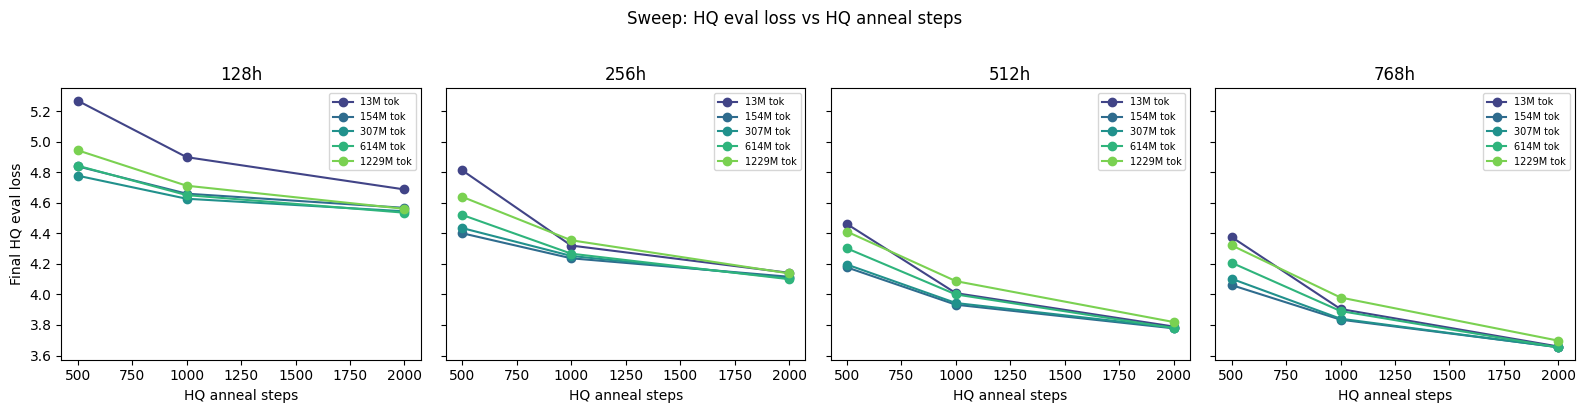

In [10]:
# Sweep only: Effect of hq_anneal_steps, faceted by model
# x-axis: hq_anneal_steps, one line per num_steps
fig, axes = plt.subplots(1, len(models_sorted), figsize=(4 * len(models_sorted), 4), sharey=True)

step_colors = plt.cm.viridis(np.linspace(0.2, 0.8, len(SWEEP_STEP_COUNTS)))

for ax, model in zip(axes, models_sorted):
    for color, ns in zip(step_colors, SWEEP_STEP_COUNTS):
        subset = df_sweep[(df_sweep["model"] == model) & (df_sweep["num_steps"] == ns)]
        subset = subset.sort_values("hq_anneal_steps")
        if len(subset) > 0:
            tokens_M = ns * 128 * 1024 / 1e6
            ax.plot(subset["hq_anneal_steps"], subset["high_loss"], "o-",
                    color=color, label=f"{tokens_M:.0f}M tok")

    ax.set_xlabel("HQ anneal steps")
    ax.set_title(f"{model}")
    ax.legend(fontsize=7)

axes[0].set_ylabel("Final HQ eval loss")
fig.suptitle("Sweep: HQ eval loss vs HQ anneal steps", y=1.02)
plt.tight_layout()
plt.show()

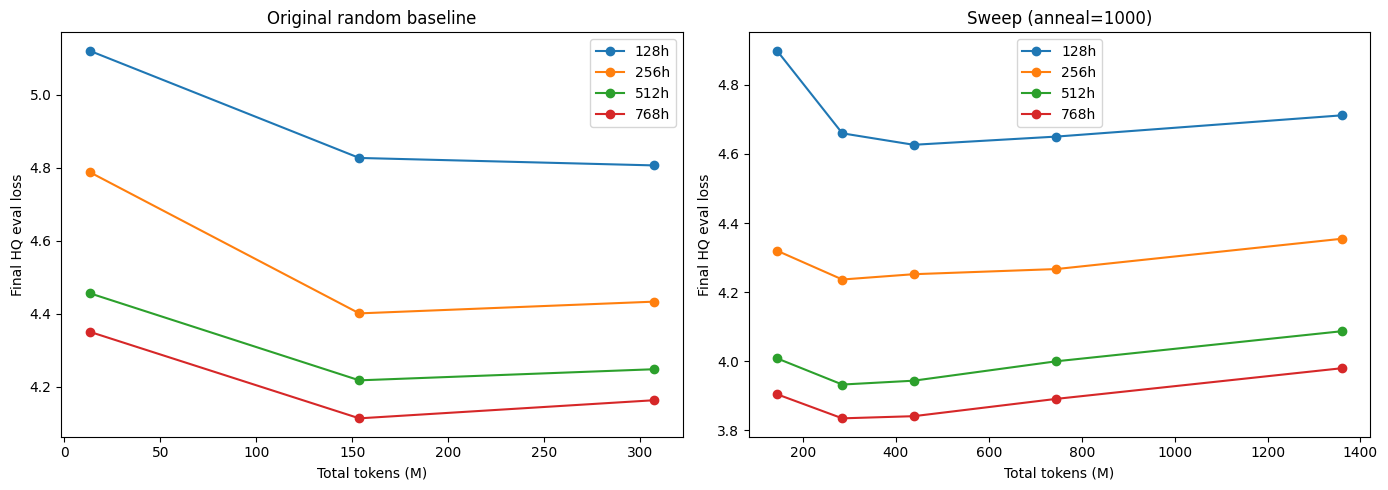

In [11]:
# Combined: all models on one plot, HQ loss vs total tokens
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: original
for model in models_sorted:
    subset = df_rand[df_rand["model"] == model].sort_values("total_tokens_M")
    if len(subset) > 0:
        axes[0].plot(subset["total_tokens_M"], subset["high_loss"], "o-", label=model)
axes[0].set_xlabel("Total tokens (M)")
axes[0].set_ylabel("Final HQ eval loss")
axes[0].set_title("Original random baseline")
axes[0].legend()

# Right: sweep (hq_anneal_steps=1000 as representative)
for model in models_sorted:
    subset = df_sweep[(df_sweep["model"] == model) & (df_sweep["hq_anneal_steps"] == 1000)].sort_values("total_tokens_M")
    if len(subset) > 0:
        axes[1].plot(subset["total_tokens_M"], subset["high_loss"], "o-", label=model)
axes[1].set_xlabel("Total tokens (M)")
axes[1].set_ylabel("Final HQ eval loss")
axes[1].set_title("Sweep (anneal=1000)")
axes[1].legend()

plt.tight_layout()
plt.show()

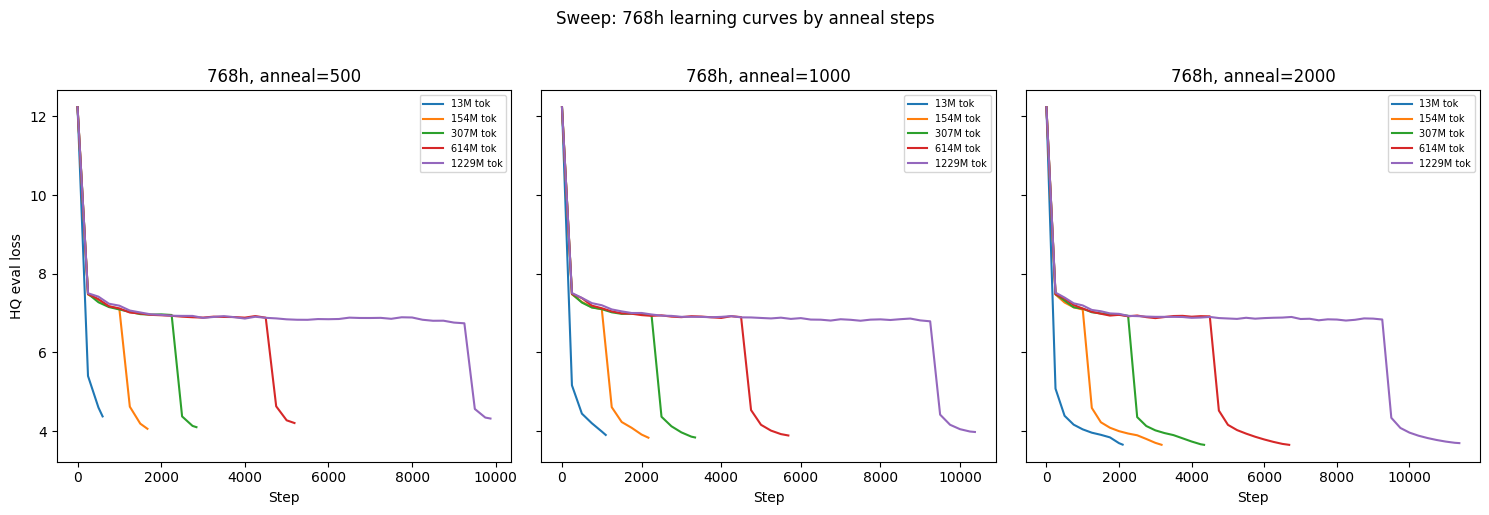

In [12]:
# Learning curves for sweep 768h model, one subplot per hq_anneal_steps
anneal_values = sorted(df_sweep["hq_anneal_steps"].unique())
fig, axes = plt.subplots(1, len(anneal_values), figsize=(5 * len(anneal_values), 5), sharey=True)

for ax, anneal in zip(axes, anneal_values):
    for step in sweep_train_steps:
        m = re.search(r"dq-iso-rand-train-(\w+)-steps(\d+)", step.name)
        if not m:
            continue
        model_name = m.group(1)
        if model_name != "768h":
            continue
        num_steps = int(m.group(2))

        total_steps = unwrap_versioned_value(step.config.train_pod_config.train_config.trainer.num_train_steps)
        step_anneal = total_steps - num_steps
        if step_anneal != anneal:
            continue

        tokens_M = num_steps * 128 * 1024 / 1e6
        out_path = sweep_executor.output_paths[step]
        try:
            records = read_eval_metrics(out_path)
        except Exception:
            continue

        steps_arr = [r["step"] for r in records]
        high_loss = [r.get("eval/high/loss") for r in records]
        ax.plot(steps_arr, high_loss, label=f"{tokens_M:.0f}M tok")

    ax.set_xlabel("Step")
    ax.set_title(f"768h, anneal={int(anneal)}")
    ax.legend(fontsize=7)

axes[0].set_ylabel("HQ eval loss")
fig.suptitle("Sweep: 768h learning curves by anneal steps", y=1.02)
plt.tight_layout()
plt.show()